### E-commerce Sales Data analysis

##### Project aim
This project aims to provide a comprehensive analysis of an e-commerce store. It explores the financial performance of the store through sales patterns, customer behaviour and revenue trends for business decision making that is data-driven.

#### Summary
This report analyzes sales data from an e-commerce store to reveal customer behavior, sales trends, regional income and product performance.

### Core insights include:

- Most sales occur on Saturdays, suggesting high demand during the weekend and first 3 days of the week.
- The months of August and Decemeber show an increase in revenue while April and October shows a decrease.
- The e-commerce store shows a steady revenue stream, with clear patterns in best-selling product category being electronic products.
- Payment method analysis shows a preference for card payment.
- Loyal customers make repeat purchases, opening up opportunities for customer retention strategies.
- Sales fluctuate throughout the weeks and months, providing insights to optimize promotions and stock levels.
- Overall, the data-driven insights suggest actionable strategies to boost sales, improve customer experience, and streamline operations.


#### Import libraries and read data

In [230]:
!pip install pandas openpyxl

In [231]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [232]:
df = pd.read_csv(r"C:\Users\menhl\AppData\Local\Temp\5a918a5c-3a46-4175-b44c-7352ce64f47c_archive (2).zip.47c\ecommerce_sales_analytics_5000.csv")

df


,order_id,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue
0,10001,1/1/2022,1102,Beauty,South,7,373.65,0.28,Wallet,10,4.7,1883.20
1,10002,1/2/2022,1435,Clothing,South,7,47.74,0.09,Card,6,3.9,304.10
2,10003,1/3/2022,1860,Beauty,East,3,311.28,0.31,COD,6,2.5,644.35
3,10004,1/4/2022,1270,Electronics,West,5,524.47,0.02,Wallet,6,1.6,2569.90
4,10005,1/5/2022,1106,Clothing,West,5,139.87,0.33,Wallet,4,4.9,468.56
...,...,...,...,...,...,...,...,...,...,...,...,...
4995,14996,9/5/2035,1289,Clothing,West,2,371.74,0.27,COD,3,2.3,542.74
4996,14997,9/6/2035,1294,Beauty,North,3,553.67,0.14,COD,11,2.2,1428.47
4997,14998,9/7/2035,1450,Beauty,West,3,77.22,0.24,Wallet,6,3.4,176.06
4998,14999,9/8/2035,1903,Electronics,South,4,138.41,0.21,COD,4,2.8,437.38


In [233]:
df.info() # Check data types and missing values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          5000 non-null   int64  
 1   order_date        5000 non-null   object 
 2   customer_id       5000 non-null   int64  
 3   product_category  5000 non-null   object 
 4   region            5000 non-null   object 
 5   quantity          5000 non-null   int64  
 6   unit_price        5000 non-null   float64
 7   discount          5000 non-null   float64
 8   payment_method    5000 non-null   object 
 9   delivery_days     5000 non-null   int64  
 10  customer_rating   5000 non-null   float64
 11  revenue           5000 non-null   float64
dtypes: float64(4), int64(4), object(4)
memory usage: 468.9+ KB


#### Data cleaning

In [234]:
#Check for duplicate rows
df.duplicated().sum()

np.int64(0)

In [235]:
# format date

df["date"] = pd.to_datetime(df["order_date"])
df = df[(df["date"].dt.year >= 2024) & (df["date"].dt.year <= 2025)]

#### Explratory Data Analysis

In [236]:
# Total Revenue and average spending per transaction
print("The total revenue: {:.1f}".format(df["revenue"].sum()))
print("The average spending between: {:.1f}".format(df["revenue"].mean()))

The total revenue: 713011.5
The average spending between: 975.4


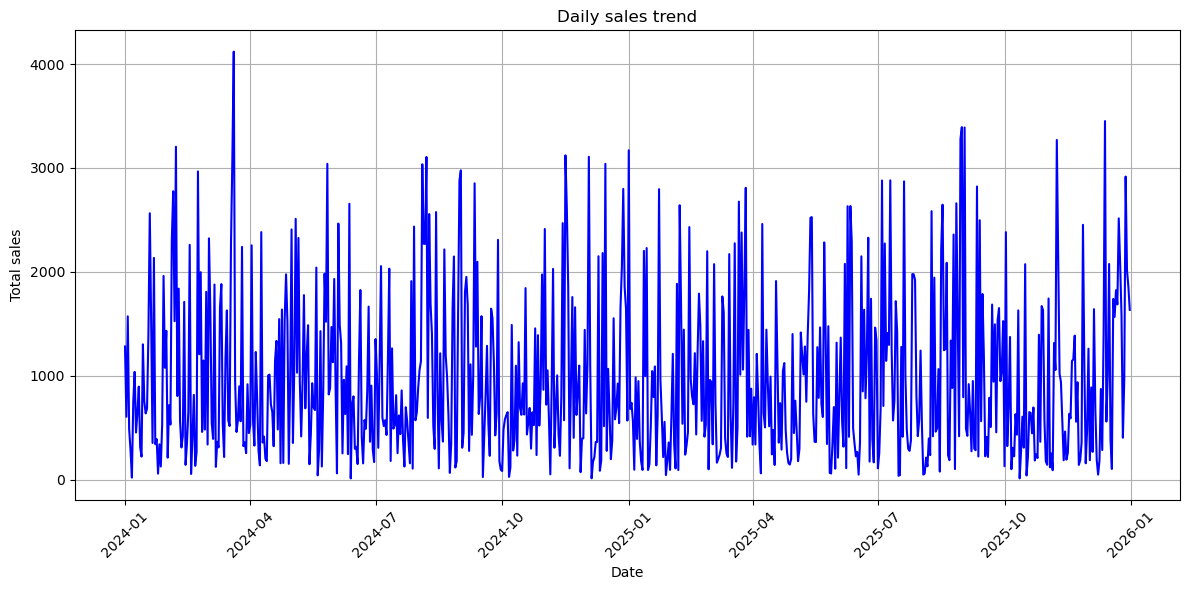

In [237]:
# Daily sales chart
daily_sales = df.groupby("date")["revenue"].sum()
plt.figure(figsize=(12,6))
plt.plot(daily_sales.index, daily_sales.values, color='b')
plt.xlabel("Date")
plt.ylabel("Total sales")
plt.title("Daily sales trend")
plt.xticks(rotation=45)
plt.grid()
plt.tight_layout()
plt.show()

# i want to make it monthly..

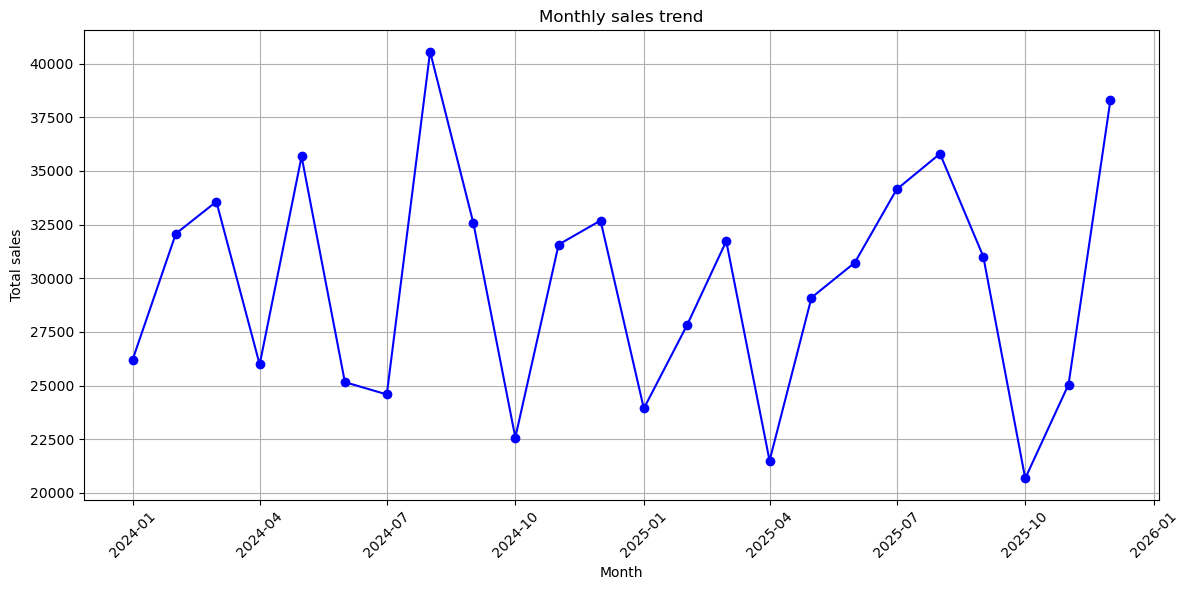

In [238]:
# monthly sales chart
monthly_sales = df.groupby(df["date"].dt.to_period("M"))["revenue"].sum()
monthly_sales.index = monthly_sales.index.to_timestamp()

plt.figure(figsize=(12,6))
plt.plot(monthly_sales.index, monthly_sales.values, color='b', marker='o')
plt.xlabel("Month")
plt.ylabel("Total sales")
plt.title("Monthly sales trend")
plt.xticks(rotation=45)
plt.grid()
plt.tight_layout()
plt.show()

#### Aggregate data

In [239]:
# Aggregating data,
# why, to find out which region, catagory generates the most revenue
grouped_df = df.groupby(['region', 'product_category']).agg(
        total_revenue=('revenue','sum')
    ).reset_index()

grouped_df

,region,product_category,total_revenue
0,East,Beauty,23099.50
1,East,Clothing,30700.33
2,East,Electronics,74084.86
3,East,Home,40662.72
4,North,Beauty,23255.43
5,North,Clothing,54087.62
6,North,Electronics,69850.02
7,North,Home,27373.14
8,South,Beauty,27158.70
9,South,Clothing,58333.18


In [240]:
# pivot table

pivot_table = df.pivot_table(
    index="region",
    columns="product_category",
    values="revenue",
    aggfunc="sum",
    fill_value=0,
    margins=True,
    margins_name="Total"
)

pivot_table

product_category,Beauty,Clothing,Electronics,Home,Total
region,,,,,
East,23099.50,30700.33,74084.86,40662.72,168547.41
North,23255.43,54087.62,69850.02,27373.14,174566.21
South,27158.70,58333.18,65303.58,39464.58,190260.04
West,20630.43,60464.84,56425.01,42117.52,179637.80
Total,94144.06,203585.97,265663.47,149617.96,713011.46


In [241]:
# Best-selling product catagory analysis
df["product_category"].value_counts()

product_category
Electronics    262
Clothing       211
Home           163
Beauty          95
Name: count, dtype: int64

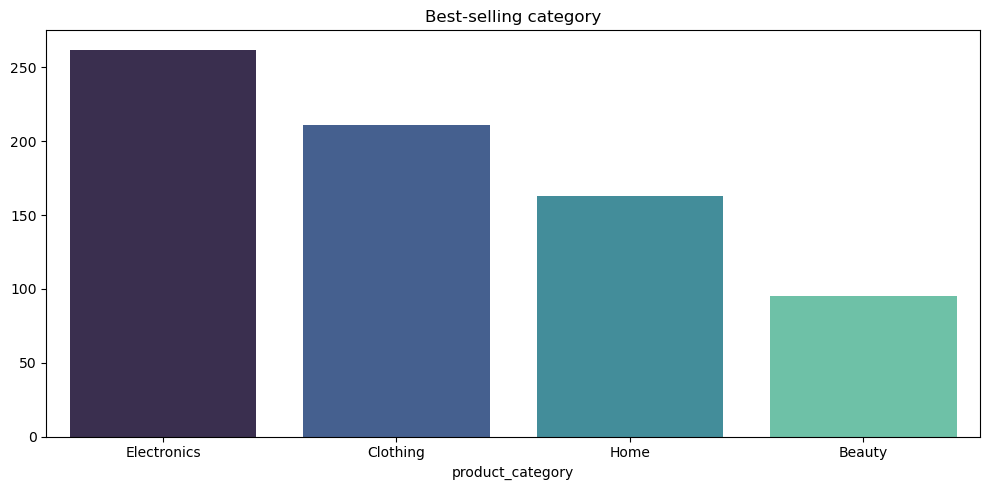

In [242]:
# Best Selling product catagory Chart
plt.figure(figsize=(10,5))
counts = df["product_category"].value_counts()
sns.barplot(x=counts.index, y=counts.values, hue=counts.index, palette="mako", legend=False)
plt.title("Best-selling category")
plt.tight_layout()
plt.show()

In [243]:
# Total revenue for each product category
df.groupby("product_category")["revenue"].sum().sort_values(ascending=False)

product_category
Electronics    265663.47
Clothing       203585.97
Home           149617.96
Beauty          94144.06
Name: revenue, dtype: float64

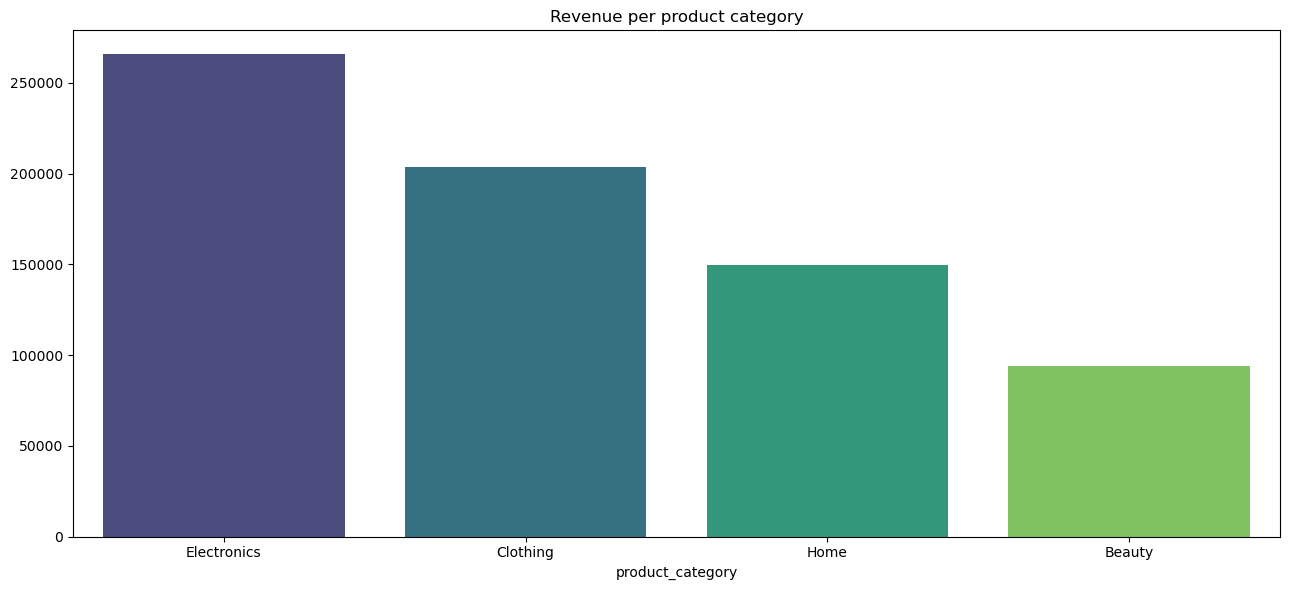

In [244]:
# Revenue for each product category Chart
product_revenue = df.groupby("product_category")["revenue"].sum().sort_values(ascending=False)

plt.figure(figsize=(13,6))
sns.barplot(x=product_revenue.index, y=product_revenue.values, hue=product_revenue.index, palette="viridis", legend=False)
plt.title("Revenue per product category")
plt.tight_layout()
plt.show()

In [245]:
# Region with the highest revenue
revenue_by_region = df.groupby("region")["revenue"].sum().sort_values(ascending=False)
print(revenue_by_region)

highest_region = revenue_by_region.idxmax()
highest_revenue = revenue_by_region.max()
print(f"\nHighest revenue region: {highest_region} ({highest_revenue})")

region
South    190260.04
West     179637.80
North    174566.21
East     168547.41
Name: revenue, dtype: float64

Highest revenue region: South (190260.04)


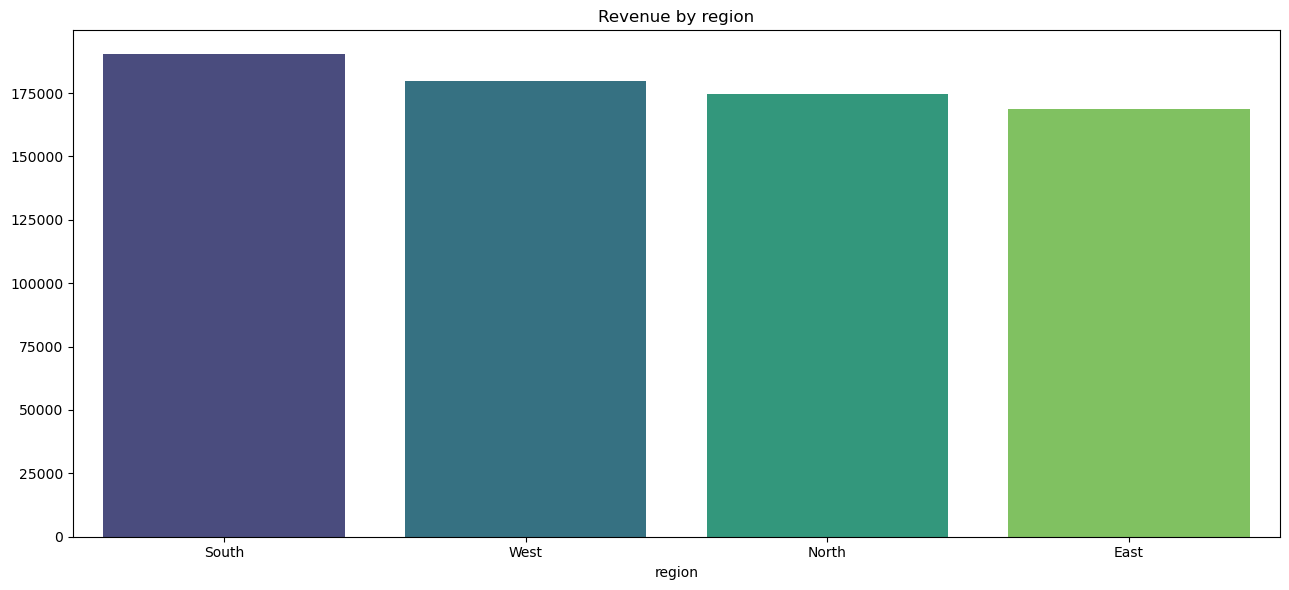

In [246]:
# Region with the highest revenue Chart
revenue_by_region = df.groupby("region")["revenue"].sum().sort_values(ascending=False)

plt.figure(figsize=(13,6))
sns.barplot(x=revenue_by_region.index, y=revenue_by_region.values, hue=revenue_by_region.index, palette="viridis", legend=False)
plt.title("Revenue by region")
plt.tight_layout()
plt.show()

In [247]:
#prefered payment option
# Payment methods distribution account
df["payment_method"].value_counts()


payment_method
Card      335
COD       271
Wallet    125
Name: count, dtype: int64

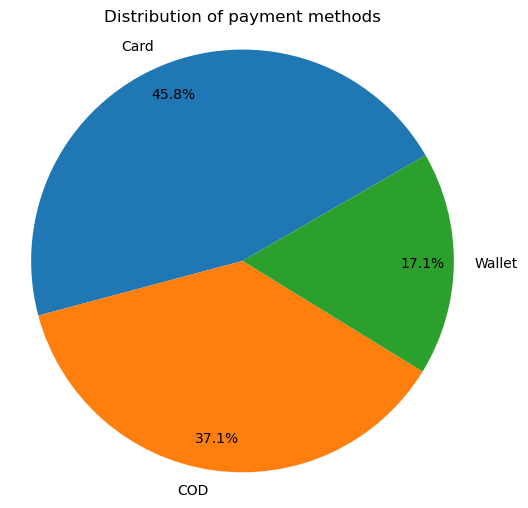

In [248]:
# pie chart of payment methods
plt.figure(figsize=(6,6))
plt.pie(df["payment_method"].value_counts(),labels=df["payment_method"].value_counts().index,
        autopct='%1.1f%%',startangle=30,pctdistance=0.85)
plt.axis('equal')
plt.title("Distribution of payment methods")
plt.show()

In [249]:
# repeat customer
# Take the top 10 customers by number of purchases
df["customer_id"].value_counts().head(10)

customer_id
1232    4
1797    4
1525    4
1228    4
1882    4
1144    4
1970    4
1077    4
1675    3
1319    3
Name: count, dtype: int64

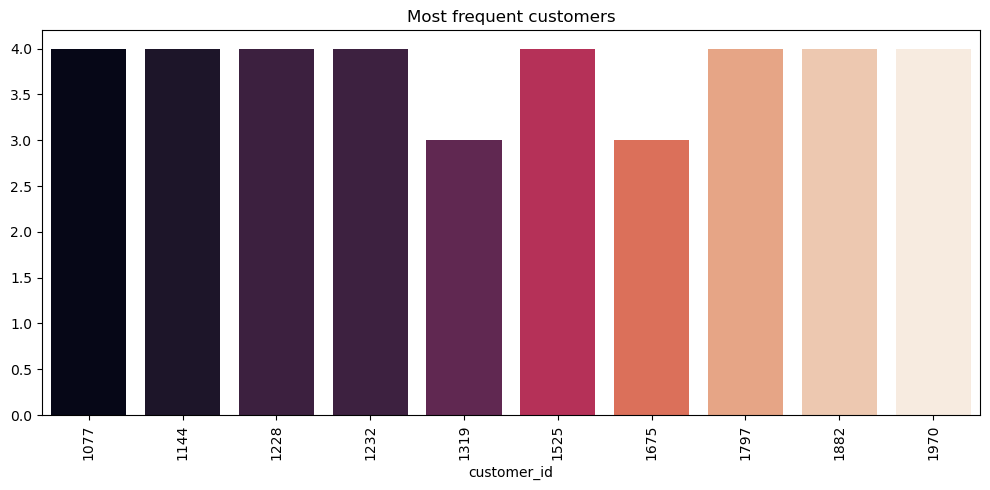

In [250]:
# Chart of repeat customers
top_customers = df["customer_id"].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_customers.index, y=top_customers.values, hue=top_customers.index, palette="rocket", legend=False)
plt.xticks(rotation=90)
plt.title("Most frequent customers")
plt.tight_layout()
plt.show()

In [251]:
# Extract days from `date`
df["weekday"]=df["date"].dt.day_name()

# Total sales for each day of the week
df.groupby("weekday")["revenue"].sum()


C:\Users\menhl\AppData\Local\Temp\ipykernel_8680\2077909811.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["weekday"]=df["date"].dt.day_name()


weekday
Friday        97641.93
Monday       104364.88
Saturday     113072.70
Sunday       101858.30
Thursday      89994.42
Tuesday      101517.08
Wednesday    104562.15
Name: revenue, dtype: float64

In [252]:
# Arrange the days correctly
sales_weekday = df.groupby("weekday")["revenue"].sum()
days_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
sales_weekday = sales_weekday.reindex(days_order)

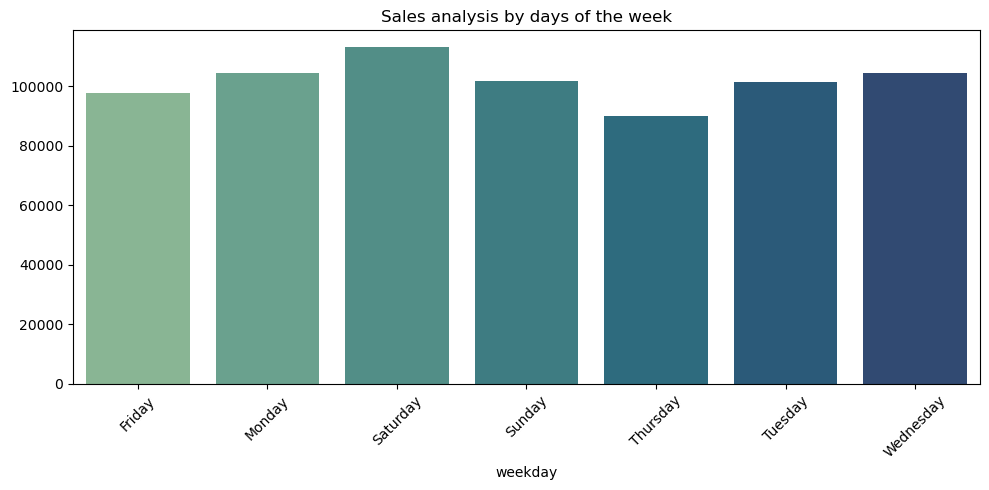

In [253]:
# Sales chart by days of the week

sales_weekday = df.groupby("weekday")["revenue"].sum()

plt.figure(figsize=(10,5))
sns.barplot(x=sales_weekday.index, y=sales_weekday.values, hue=sales_weekday.index, palette="crest", legend=False)
plt.title("Sales analysis by days of the week")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [254]:
# Extract months from `date`
df["month"] = df["date"].dt.month
# Monthly sales
df.groupby("month")["revenue"].sum()

C:\Users\menhl\AppData\Local\Temp\ipykernel_8680\2752511207.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["month"] = df["date"].dt.month


month
1     50133.08
2     59902.89
3     65298.23
4     47487.99
5     64772.89
6     55889.71
7     58729.11
8     76354.17
9     63570.33
10    43261.96
11    56620.15
12    70990.95
Name: revenue, dtype: float64

C:\Users\menhl\AppData\Local\Temp\ipykernel_8680\106134768.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["month"] = df["date"].dt.month_name()


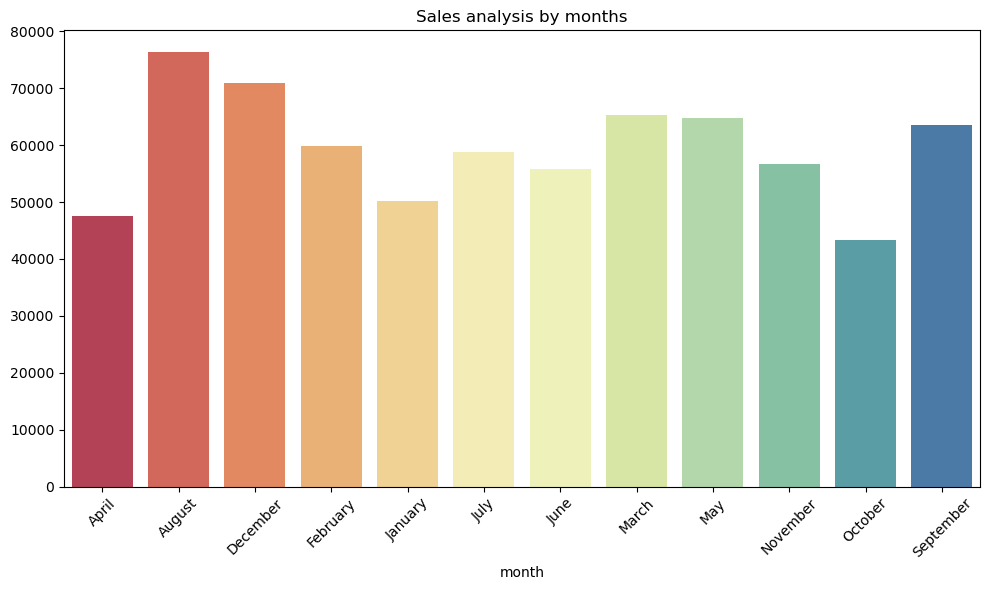

In [255]:
# Sales chart by months

df["month"] = df["date"].dt.month_name()
sales_monthly = df.groupby("month")["revenue"].sum()

plt.figure(figsize=(10,6))
sns.barplot(x=sales_monthly.index, y=sales_monthly.values, hue=sales_monthly.index, palette="Spectral", legend=False)
plt.title("Sales analysis by months")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


#### Conclusions and findings

- The total revenue generated by the e-commerce is significant, with an average transaction amount that shows healthy customer spending behavior.
- The best-selling product category is electronics and least selling is beauty as identified through frequency analysis, allowing for better inventory management and restocking decisions.
- The daily sales trend shows that Saturday consistently outperform other days.
- Payment method distribution reveals a preference pattern, with card payment being the dominant mode, closely fllowed by cash on delivery.
- A small group of loyal/repeat customers is responsible for a significant portion of sales, suggesting potential for targeted loyalty programs.
- Monthly sales analysis highlights seasonal trends or fluctuations that could guide promotional campaigns. August and December shows highe revenue as compared to other months.

#### Recommendations

- Consider offering promotions during non-peak days like Thursday and Friday, as well as non-peak months like April and October to balance the sales load.
- Analyze customer cards further to identify demographics behind loyal customers.
- Monitor the beauty category which is the least popular products to assess if they should be replaced or promoted differently.
